In [30]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

import autoslo.filesystem.path_utils as pu
from autoslo.filesystem.logos_export import logos_df
from autoslo.filesystem.structured_log import StructuredLog
from autoslo.slo.slo_resolver import SloResolver
from autoslo.config.component_configs import SloResolverConfig
from autoslo.filesystem.yaml_helpers import load_yaml
from logos import Logos
from IPython.display import Image
from logos.preparation.prepared_variable_name import PreparedVariableName
from logos.parsing.parsed_variable_name import ParsedVariableName
from logos.parsing.tag_utils import name_of, tag_of



In [2]:
RUN_ID = "1783260865180"

In [3]:
exec_cfg = load_yaml(pu.get_runs_dir() / RUN_ID / "execution_config.yml")
resolver = SloResolver(
    SloResolverConfig(
        slo_s=exec_cfg["slo_resolver_config"]["slo_s"],
        slo_dict_filename=exec_cfg["slo_resolver_config"]["slo_dict_filename"],
    )
)
df = logos_df(
    run_id=RUN_ID,
    slo_resolver=resolver,
    drop_fwd_queries=True,
    include_named_query_features=True,
    include_overlap_counts=True,
)

Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/model_v8/model_1782160265.pth


In [4]:
print(df.shape)
print(df.columns)

(21268, 94)
Index(['wall_clock_s', 'rel_time_s', 'source', 'event_type', 'query_id',
       'query_text_id', 'cluster_name', 'reason', 'workload_name',
       'num_queries', 'routing_policy', 'closed_loop', 'latency_s_for_routing',
       'slo_violation', 'cost', 'cache_risk', 'old_latency_s', 'success',
       'copy_idx', 'phase', 'candidate_rpu', 'started_after_ready', 'rpu',
       'slo_threshold', 'autoscaling_policy', 'autoscaling_trigger_policy',
       'num_active_clusters', 'scheduled_rel_time_s', 'force', 'action_reason',
       'max', 'used', 'reserved', 'available', 'observed_latency_s', 'slo_s',
       'observed_latency_over_slo', 'observed_slo_violation',
       'routed_cluster_name', 'routed_cluster_rpu', 'predicted_latency_s',
       'predicted_latency_over_slo', 'XN Seq Scan#count',
       'XN Seq Scan#cardinality', 'XN Hash#count', 'XN Hash#cardinality',
       'XN Hash Join DS_DIST_ALL_NONE#count',
       'XN Hash Join DS_DIST_ALL_NONE#cardinality', 'XN Subquery Scan#

In [ ]:
per_query_id_constant_cols = [
    c for c in df.columns if df.groupby("query_id")[c].nunique().max() == 1
]

lg = Logos.from_parsed_table(
    data=df,
    workdir=".",
    source_id="structured_log_p40",
    template_col="event_type",
    passthrough_cols=["wall_clock_s", "rel_time_s"],
    per_unit_cols=per_query_id_constant_cols,
)

In [6]:
lg.parsed_variables

,Name,Tag,TagOrigin,Type,IsUninteresting,Occurrences,Preceding 3 tokens,Examples,From regex
0,c3463bd0_0,spin_up_requested source,4,str,False,10,[],[ManagedClusterPool],False
1,c3463bd0_1,spin_up_requested cluster_name,4,str,False,10,[],[],False
2,c3463bd0_2,spin_up_requested reason,4,str,False,10,[],"[initial, observation_window_start_s=3108.0634...",False
3,508f04e8_0,spin_up_started source,4,str,False,10,[],[RedshiftServerlessProvisioner],False
4,508f04e8_1,spin_up_started cluster_name,4,str,False,10,[],"[autoslo-32-1783260865180-0, autoslo-32-178326...",False
...,...,...,...,...,...,...,...,...,...
136,51320c12_0,store#cardinality,4,num,False,21164,[],"[0.0, 5.123964038927067, 8.452548000056266, 9....",True
137,ff99bb26_0,reason#cardinality,4,num,False,21164,[],"[0.6931521805474454, 0.0, 2.0794427916790545, ...",True
138,87442d18_0,web_site#cardinality,4,num,False,21164,[],"[0.0, 6.553933418270825, 7.167037884628269]",True
139,f1db3404_0,num_active_at_start,4,num,False,11020,[],"[0.0, 1.0, 2.0, 3.0, 4.0]",True


In [7]:
lg.set_causal_unit("query_id")

In [8]:
lg.prepare(default_imp="zero_imp", force=True)

Imputing missing values...:   0%|          | 0/270 [00:00<?, ?it/s]

One-hot encoding categorical variables...:   0%|          | 0/18 [00:00<?, ?it/s]

In [9]:
lg.prepared_variables

,Name,Base,Pre-agg Value,Agg,Post-agg Value,Tag,Base Variable Occurences,Type,Examples,From regex,TemplateText
0,ebdcf81f_2+mean,ebdcf81f_2,,mean,,routing_score latency_s_for_routing mean,10144,num,"[15.494, 17.444, 17.443, 23.051, 26.054]",False,routing_score
1,ebdcf81f_3+mean,ebdcf81f_3,,mean,,routing_score slo_violation mean,10144,num,"[0.0, 0.5, 0.167, 0.143, 0.25]",False,routing_score
2,ebdcf81f_4+mean,ebdcf81f_4,,mean,,routing_score cost mean,10144,num,"[0.0, 0.2, 0.4, 0.6, 0.8]",False,routing_score
3,ef3b209b_2+mean,ef3b209b_2,,mean,,routing latency_s_for_routing mean,1392,num,"[15.494, 17.444, 17.443, 23.051, 26.054]",False,routing
4,ef3b209b_3+mean,ef3b209b_3,,mean,,routing slo_violation mean,1392,num,"[0.0, 0.5, 0.167, 0.143, 0.25]",False,routing
...,...,...,...,...,...,...,...,...,...,...,...
229,ecd3b58c_0+last=autoslo-16-1783260865180-8,ecd3b58c_0,,last,autoslo-16-1783260865180-8,routed_cluster_name last autoslo-16-1783260865...,21164,str,"[autoslo-32-1783260865180-0, autoslo-32-178326...",True,
230,ecd3b58c_0+last=autoslo-16-1783260865180-9,ecd3b58c_0,,last,autoslo-16-1783260865180-9,routed_cluster_name last autoslo-16-1783260865...,21164,str,"[autoslo-32-1783260865180-0, autoslo-32-178326...",True,
231,ecd3b58c_0+last=autoslo-32-1783260865180-0,ecd3b58c_0,,last,autoslo-32-1783260865180-0,routed_cluster_name last autoslo-32-1783260865...,21164,str,"[autoslo-32-1783260865180-0, autoslo-32-178326...",True,
232,ecd3b58c_0+last=autoslo-32-1783260865180-1,ecd3b58c_0,,last,autoslo-32-1783260865180-1,routed_cluster_name last autoslo-32-1783260865...,21164,str,"[autoslo-32-1783260865180-0, autoslo-32-178326...",True,


In [10]:
lg.clear_graph()

In [11]:
lg.rank_candidate_causes("observed_slo_violation mean")

,Candidate,Candidate Tag,Target Tag,Slope,P-value,Candidate->Target Edge Status,Target->Candidate Edge Status
0,c9db7d03_0+mean,observed_latency_s mean,observed_slo_violation mean,0.001412,7.565146e-74,Undecided,Undecided
1,f1db3404_0+mean,num_active_at_start mean,observed_slo_violation mean,0.036349,7.185237e-51,Undecided,Undecided


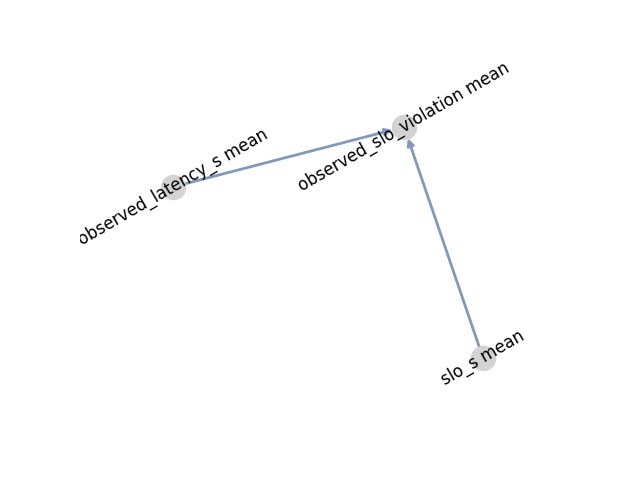

In [12]:
lg.accept("observed_latency_s mean", "observed_slo_violation mean")
lg.accept("slo_s mean", "observed_slo_violation mean")
lg.save_graph("/tmp/g.png") or Image("/tmp/g.png")

In [13]:
lg.rank_candidate_causes("observed_latency_s mean")

,Candidate,Candidate Tag,Target Tag,Slope,P-value,Candidate->Target Edge Status,Target->Candidate Edge Status
0,17a1a008_0+mean,observed_latency_over_slo mean,observed_latency_s mean,4.744908e+00,2.075581e-76,Undecided,Undecided
1,2f4a6473_0+mean,wall_clock_s mean,observed_latency_s mean,2.089018e-08,5.816744e-44,Undecided,Undecided
2,c999aa2f_0+mean,num_arrived_during mean,observed_latency_s mean,6.535614e+00,8.774796e-17,Undecided,Undecided
3,f1db3404_0+mean,num_active_at_start mean,observed_latency_s mean,6.340178e+00,6.073488e-15,Undecided,Undecided
4,ebdcf81f_2+mean,routing_score latency_s_for_routing mean,observed_latency_s mean,1.968516e+00,4.148356e-14,Undecided,Undecided
5,3609b411_2+mean,latency_update old_latency_s mean,observed_latency_s mean,1.192426e+00,2.221659e-13,Undecided,Undecided
6,ebdcf81f_3+mean,routing_score slo_violation mean,observed_latency_s mean,8.793967e+01,1.194245e-06,Undecided,Undecided
7,3609b411_0+last=0,latency_update source last 0,observed_latency_s mean,-2.523234e+01,3.307114e-06,Undecided,Undecided
8,ef3b209b_3+mean,routing slo_violation mean,observed_latency_s mean,8.182724e+01,1.374750e-05,Undecided,Undecided
9,407bba4a_0+mean,routed_cluster_rpu mean,observed_latency_s mean,1.731781e+00,2.655190e-05,Undecided,Undecided


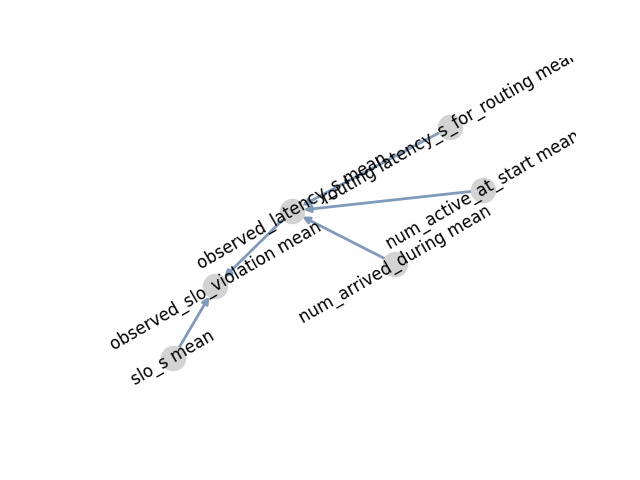

In [14]:
lg.accept("num_arrived_during mean", "observed_latency_s mean")
lg.accept("num_active_at_start mean", "observed_latency_s mean")
lg.accept("routing latency_s_for_routing mean", "observed_latency_s mean")
lg.save_graph("/tmp/g.png") or Image("/tmp/g.png")

In [ ]:
src = "num_arrived_during mean"
tgt = "observed_latency_s mean"

In [19]:
print(lg.get_adjusted_ate(src, tgt))

5.668651962201732


In [21]:
sug1, sug2 = lg.get_causal_graph_refinement_suggestion(src, tgt)
sug1, sug2

('latency_update old_latency_s mean', 'num_arrived_during mean')

In [22]:
lg.accept(sug1, sug2)
print(lg.get_adjusted_ate(src, tgt))
lg.get_causal_graph_refinement_suggestion(src, tgt)

5.668651962201732


('latency_update old_latency_s mean', 'observed_latency_s mean')

In [37]:
def cond(x):
    return "#" in tag_of(lg.parsed_variables, x)


names_of_plan_variables = lg.prepared_variables[
    lg.prepared_variables["Base"].apply(cond)
]["Name"].to_list()

In [40]:
for n in names_of_plan_variables:
    lg.accept(n, "observed_latency_s mean")
    lg.accept(n, "latency_update old_latency_s mean")
    lg.accept(n, "slo_s mean")

In [41]:
print(lg.get_adjusted_ate(src, tgt))


4.4390404367971215


In [42]:
print(lg.get_adjusted_ate(src, 'observed_slo_violation mean'))

0.030209746282961986


In [43]:
print(lg.get_unadjusted_ate(src, 'observed_slo_violation mean'))

0.022994021690034963
